---
numbering: false
---

# 2.8: Systems of linear equations

We have described lines and planes using linear equations. What happens when we require a point to satisfy **several equations at once**? Geometrically, we are looking for the intersection of the corresponding lines or planes.

We'll begin with two equations in two variables, then use lines and planes to explore larger systems. Finally, we'll see why engineering problems can require thousands of equations and why we need a way to solve systems without drawing them.

In [1]:
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
import sys
_notes_root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'myst.yml').exists())
sys.path.insert(0, str(_notes_root))
from plot_style import style_plotly
BLUE, ORANGE, PINK = '#3d81f6', 'orange', '#d81a60'

---

## Linear equations and their solutions

A **linear equation** in the variables $x_1,\ldots,x_n$ has the form

$$a_1x_1+\cdots+a_nx_n=b,$$

where the coefficients $a_1,\ldots,a_n$ and the right-hand side $b$ are fixed numbers. The variables appear only to the first power, and we do not multiply variables together. For example, $2x-3y=5$ is linear, while $x^2+y=5$ and $xy=5$ are not.

:::{note} Definition: System of linear equations
A **system of linear equations**, or **linear system**, is a collection of linear equations in the same variables. A **solution** is a choice of values for those variables that satisfies **every equation simultaneously**. The **solution set** consists of all such choices.
:::

The number of equations need not equal the number of variables. Three equations in $x$ and $y$ still describe points in $\mathbb R^2$; three equations in $x$, $y$, and $z$ describe points in $\mathbb R^3$.

For our geometric examples, each equation has at least one nonzero variable coefficient. Thus, an equation in two variables describes a line, and an equation in three variables describes a plane.

---

## Two equations in two variables

Consider

$$\begin{cases}a_1x+b_1y=c_1,\\a_2x+b_2y=c_2.\end{cases}$$

Each equation describes a line. A solution belongs to **both** lines, so the solution set is their intersection. There are three possibilities.

| Arrangement | Common solution set | Number of solutions |
| :--- | :--- | :--- |
| Two lines intersect at one point | A point | One |
| Two distinct parallel lines | The empty set | None |
| Two coincident lines | The entire line | Infinitely many |

**Coincident** means that the two equations describe the same line, even if the equations look different.

### Example: One solution

Consider the system:

$$\begin{cases}y=0,\\y=x.\end{cases}$$

The first equation forces $y=0$, and the second then forces $x=0$. The only solution is $(0,0)$, where the lines intersect.

### Example: No solutions

$$\begin{cases}y=1,\\y=-1.\end{cases}$$

No point can have both $y=1$ and $y=-1$. These are distinct parallel lines, so their intersection is empty.

### Example: Infinitely many solutions

$$\begin{cases}x-y=0,\\2x-2y=0.\end{cases}$$

The second equation is twice the first, so it adds no new restriction. Both describe $y=x$. The solution set is

$$\left\{\begin{bmatrix}t\\t\end{bmatrix}:t\in\mathbb R\right\}.$$

```{figure} #plot-28-two-lines
:label: fig-28-two-lines
:class: course-caption
:alt: Two lines meet at the origin, two horizontal lines are parallel and distinct, or two diagonal lines coincide.

Two lines can share one point, no points, or every point on a line. In the last panel, the dashed orange line lies on top of the blue line.
```

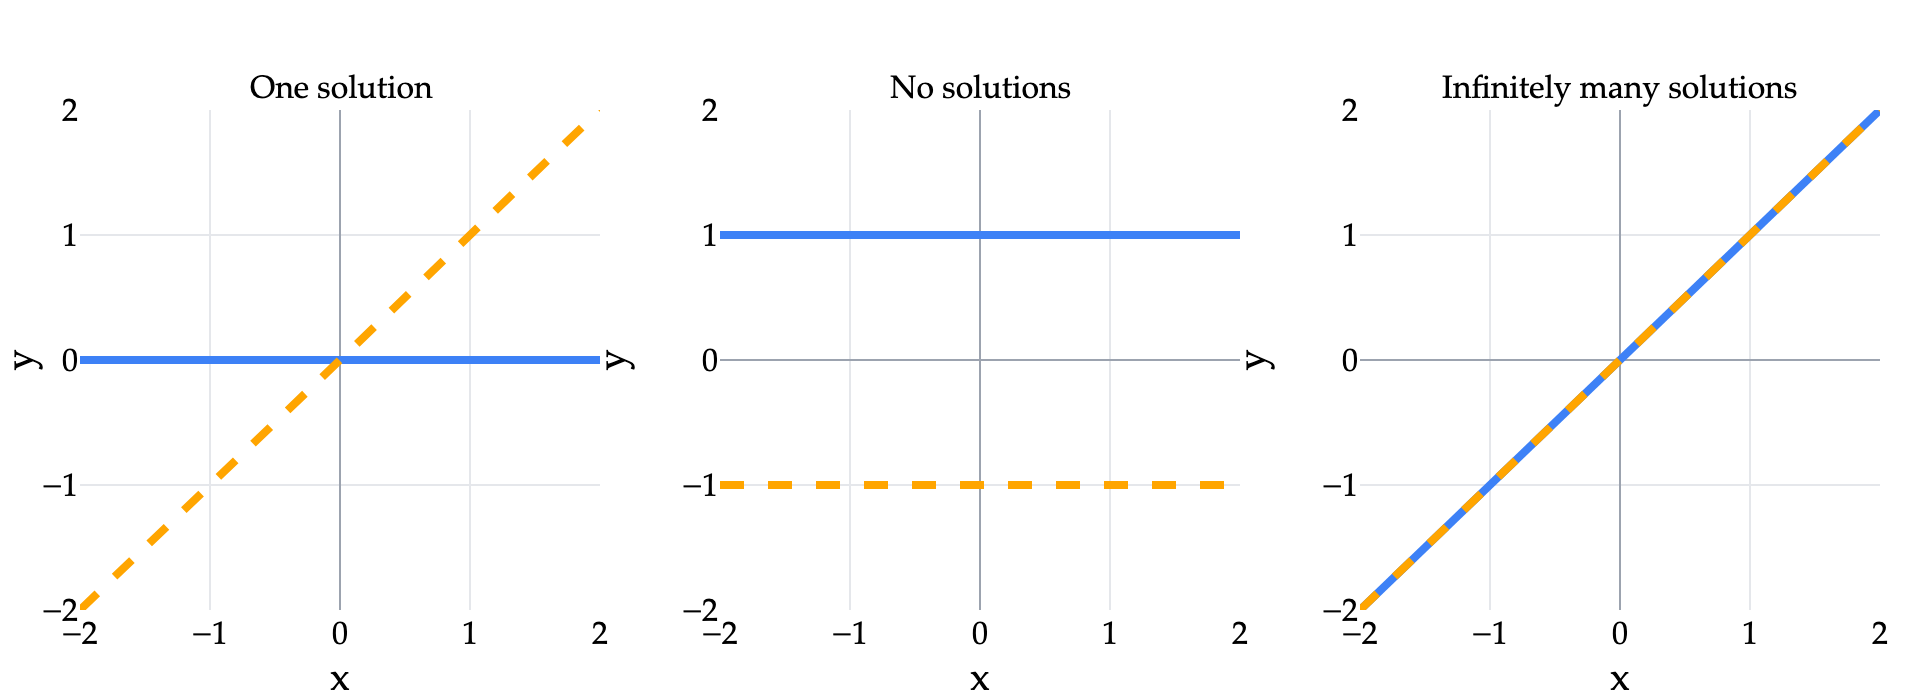

In [2]:
fig=style_plotly(make_subplots(rows=1,cols=3,subplot_titles=['One solution','No solutions','Infinitely many solutions']))
t=np.linspace(-2,2,100)
cases=[[(t,0*t),(t,t)],[(t,0*t+1),(t,0*t-1)],[(t,t),(t,t)]]
for col,lines in enumerate(cases,1):
    for j,(x,y) in enumerate(lines):
        fig.add_trace(go.Scatter(x=x,y=y,mode='lines',line=dict(color=[BLUE,ORANGE][j],width=4,dash='dash' if j else 'solid'),showlegend=False),row=1,col=col)
fig.update_xaxes(range=[-2,2],dtick=1,title_text='x')
fig.update_yaxes(range=[-2,2],dtick=1,title_text='y')
fig.update_layout(width=960,height=350,font=dict(size=16),margin=dict(l=40,r=20,t=55,b=45))
fig.show(renderer='png',scale=2)

---

## More equations and homogeneous systems

Adding an equation means keeping only the points that also satisfy that equation. It can shrink the solution set or leave it unchanged; it can never add new solutions.

For example, $y=0$ and $x=0$ meet at the origin. Adding $x+y=2$ leaves **no** common solution. Each pair of lines intersects, but the three lines do not share a point. A solution of a system must satisfy all of its equations, not just some pair.

:::{note} Definition: Homogeneous system
A linear system is **homogeneous** if every right-hand side is zero when each equation is written as a linear combination of the variables equal to a constant.

For example, $y=x$ can be written as $x-y=0$. The system $y=0$, $y=x$, $y=-x$ is homogeneous.
:::

Every homogeneous system has the **zero solution**, obtained by setting all variables to zero. Geometrically, all its lines or planes pass through the origin. A homogeneous system can therefore never have an empty solution set.

The converse needs care: a system can have solutions without being homogeneous. For instance, $x=1$, $y=2$ has the solution $(1,2)$, but it is not homogeneous in these coordinates.

::::{tip} Activity 1: Three equations in two variables
For each picture below, write three linear equations in $x$ and $y$ with the same arrangement, listing $L_1,L_2,L_3$ in that order. The exact slopes and spacing need not match.

1. Describe the points that satisfy all three equations.
2. Decide which pictures could represent a homogeneous system. No coordinate axes are shown, so you may choose where to place the origin.

Each equation must describe a genuine line: at least one coefficient of $x$ or $y$ must be nonzero. Equations such as $0=0$ and $0=5$ are not allowed here.

```{figure} #plot-28-activity-lines
:label: fig-28-activity-lines
:class: course-caption
:alt: Seven arrangements A through G: three concurrent lines, a triangle, two parallel lines and a transversal, three parallel lines, two coincident lines and a transversal, two coincident lines and a distinct parallel line, and three coincident lines.

Configurations A–G. Labels with an equals sign indicate coincident lines.
```

:::{tip} Solution
:class: dropdown

One choice of equations for each picture is below. The equations in each row are listed in the order $L_1,L_2,L_3$.

| Case | Equations | Common solution set |
| :--- | :--- | :--- |
| A | $y=0$; $y=x$; $y=-x$ | The point $(0,0)$ |
| B | $y=0$; $x=0$; $x+y=2$ | Empty |
| C | $y=1$; $y=-1$; $y=x$ | Empty |
| D | $y=1$; $y=0$; $y=-1$ | Empty |
| E | $y=0$; $2y=0$; $y=x$ | The point $(0,0)$ |
| F | $y=1$; $2y=2$; $y=-1$ | Empty |
| G | $x-y=0$; $2x-2y=0$; $3x-3y=0$ | The line $y=x$ |

**A, E, and G** can represent homogeneous systems. Place the origin at the common intersection in A and E, or anywhere on the common line in G. The other configurations have no common point, so no choice of origin can put it on every line.

To see why there are seven cases, count distinct lines. One distinct line gives G. Two distinct lines either intersect (E) or are parallel (F). With three distinct lines, they are all parallel (D), exactly two are parallel (C), all three meet at one point (A), or their pairwise intersections form a triangle (B).
:::
::::

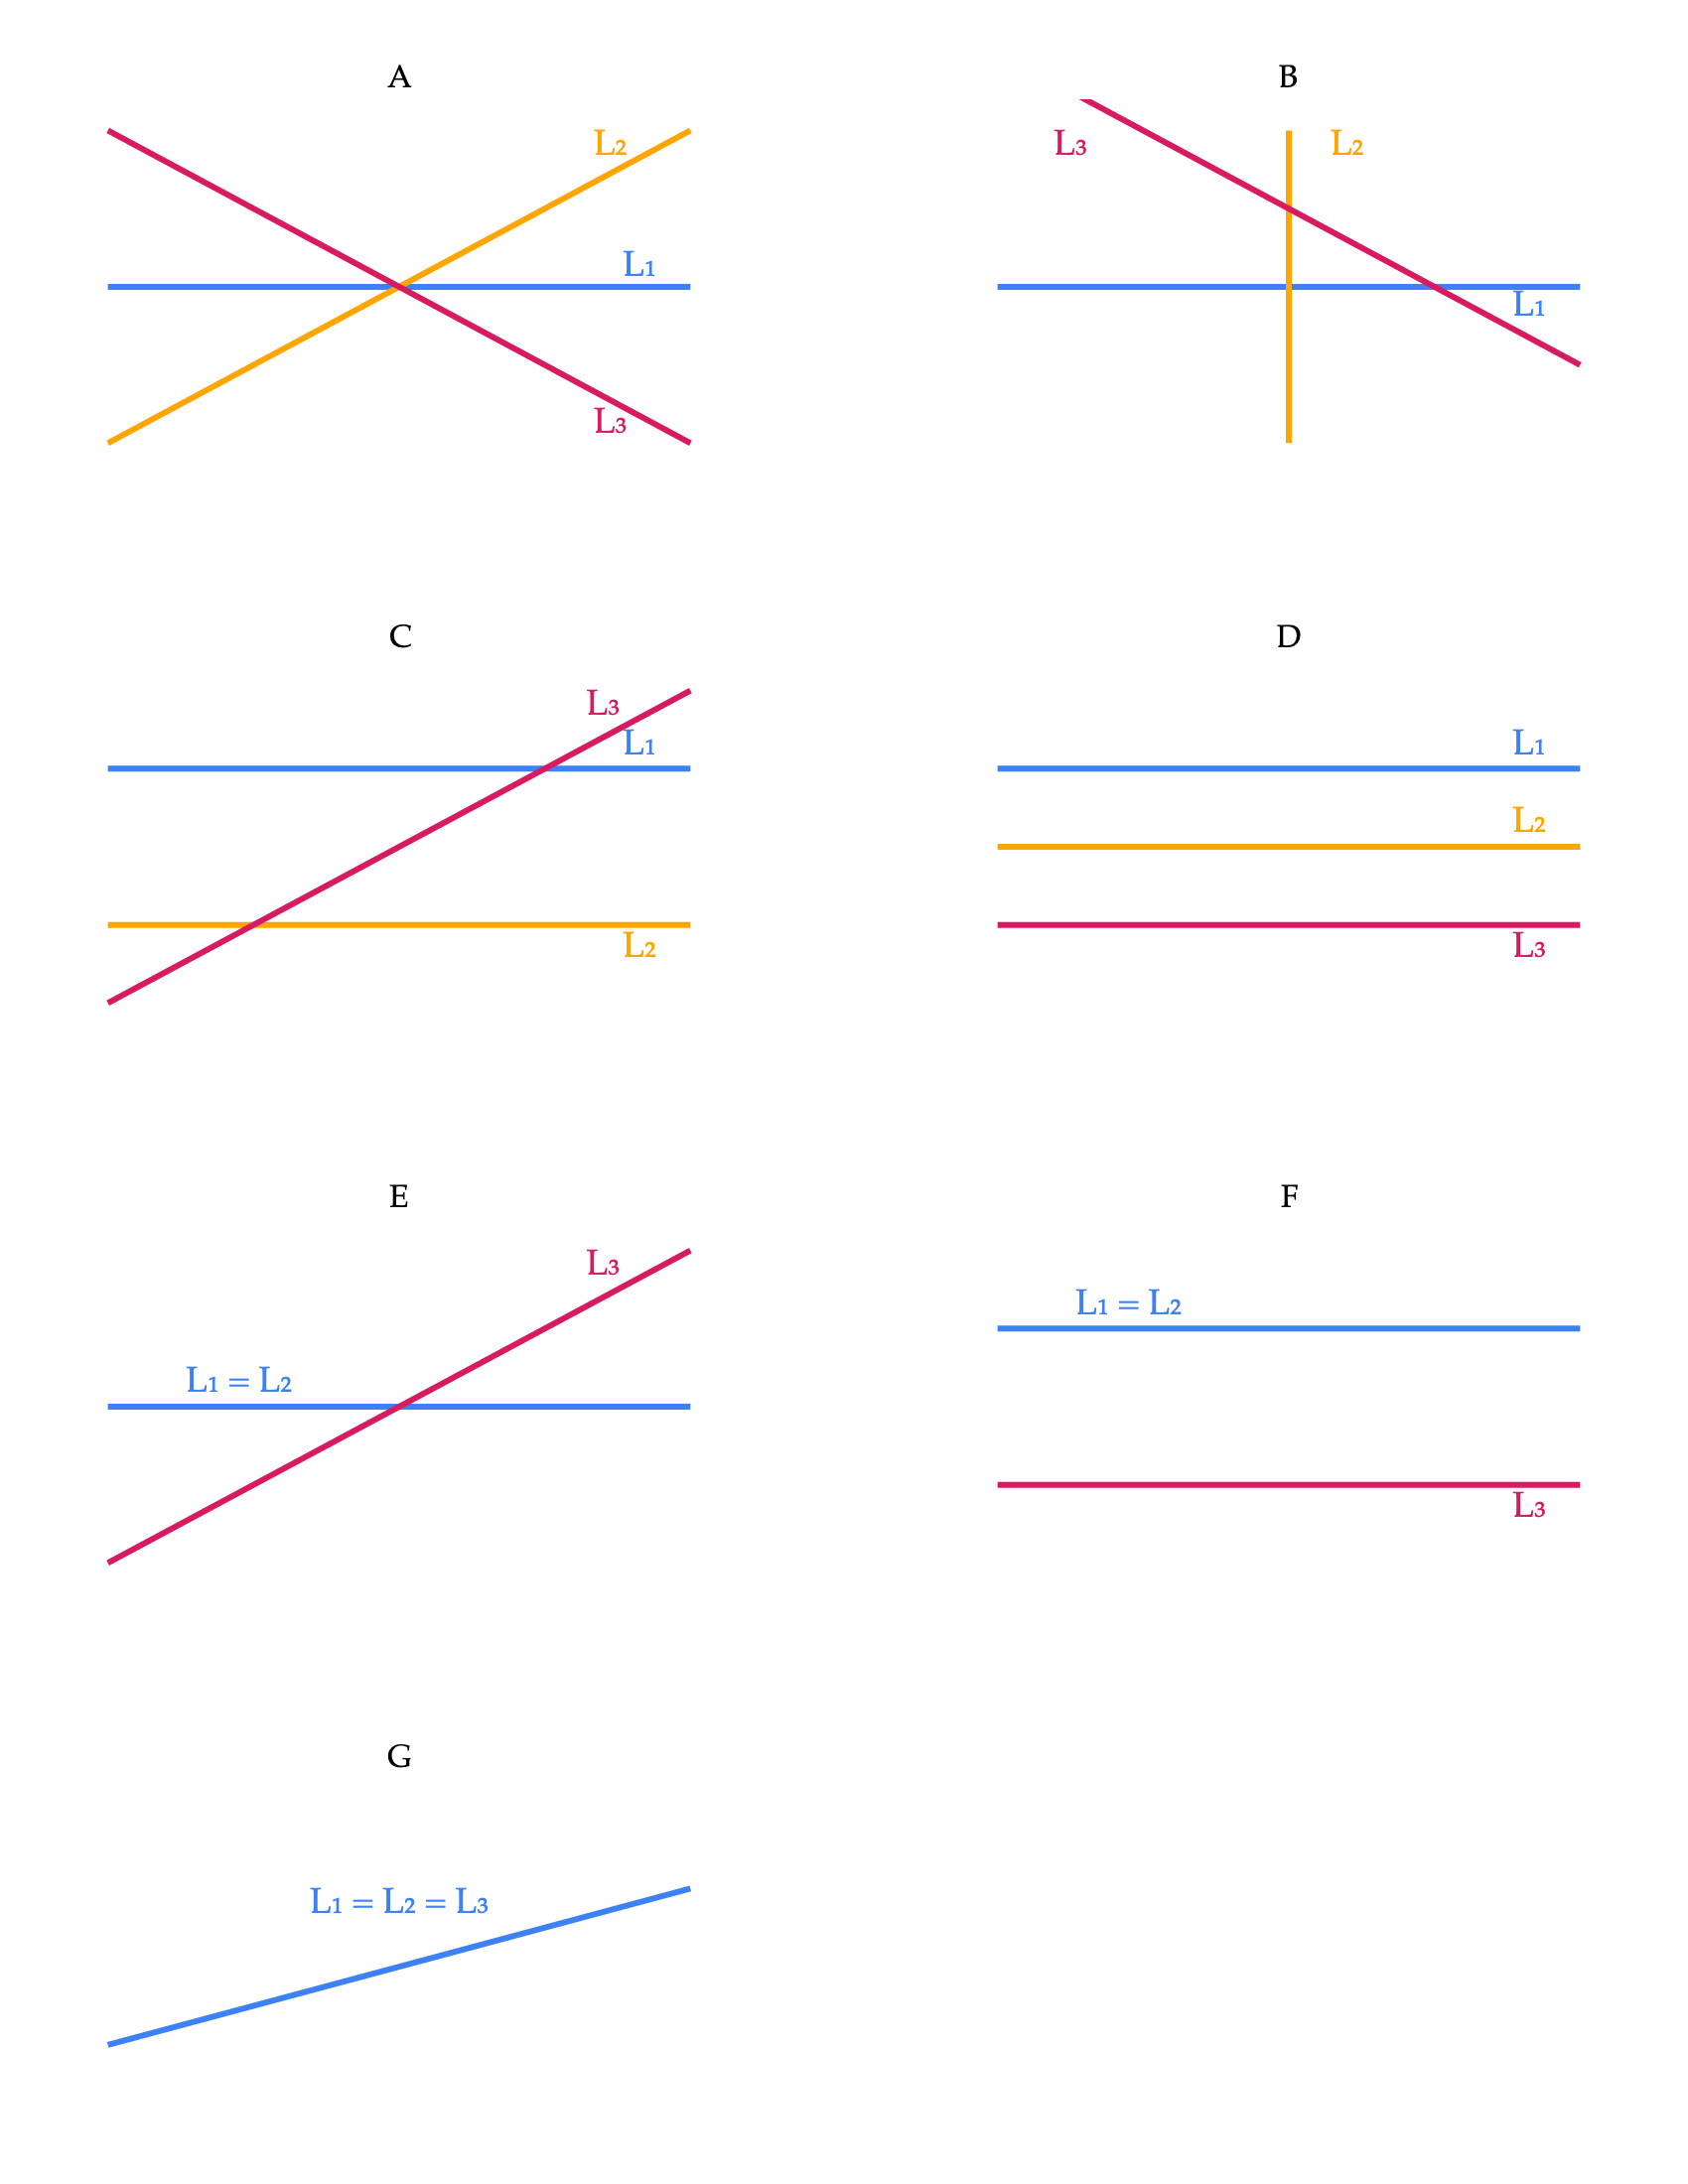

In [3]:
fig=style_plotly(make_subplots(rows=4,cols=2,subplot_titles=list('ABCDEFG')+[''],vertical_spacing=.09,horizontal_spacing=.12))
t=np.linspace(-2,2,100)
configs=[[(t,0*t),(t,t),(t,-t)],[(t,0*t),(0*t,t),(t,1-t)],[(t,0*t+1),(t,0*t-1),(t,t)],[(t,0*t+1),(t,0*t),(t,0*t-1)],[(t,0*t),(t,t)],[(t,0*t+1),(t,0*t-1)],[(t,.5*t)]]
labels=[['L₁','L₂','L₃']]*4+[['L₁ = L₂','L₃'],['L₁ = L₂','L₃'],['L₁ = L₂ = L₃']]
positions=[[(1.65,.25),(1.45,1.8),(1.45,-1.75)],[(1.65,-.25),(.4,1.8),(-1.5,1.8)],[(1.65,1.3),(1.65,-1.3),(1.4,1.8)],[(1.65,1.3),(1.65,.3),(1.65,-1.3)],[(-1.1,.3),(1.4,1.8)],[(-1.1,1.3),(1.65,-1.3)],[(0,.8)]]
for k,lines in enumerate(configs):
    row,col=k//2+1,k%2+1
    for j,((x,y),label,(lx,ly)) in enumerate(zip(lines,labels[k],positions[k])):
        color=[BLUE,ORANGE,PINK][j if k<4 else (0 if j==0 else 2)]
        fig.add_trace(go.Scatter(x=x,y=y,mode='lines',line=dict(color=color,width=3),showlegend=False),row=row,col=col)
        fig.add_trace(go.Scatter(x=[lx],y=[ly],mode='text',text=[label],textfont=dict(color=color,size=18),showlegend=False),row=row,col=col)
fig.update_xaxes(range=[-2.4,2.4],visible=False)
fig.update_yaxes(range=[-2.4,2.4],visible=False)
fig.update_layout(width=850,height=1100,margin=dict(l=25,r=25,t=50,b=15),font=dict(size=18))
fig.show(renderer='png',scale=2)

---

## Three equations in three variables

In $\mathbb R^3$, each equation $ax+by+cz=d$ describes a plane when its normal vector is nonzero. Solving a system means finding the intersection of **all** the planes.

### Start with two planes

Before trying to picture three planes at once, consider just $P_1$ and $P_2$. There are only three possibilities:

| Relationship between $P_1$ and $P_2$ | Their intersection | Example |
| :--- | :--- | :--- |
| Distinct and parallel | No points | $z=0$ and $z=1$ |
| Distinct and nonparallel | A line | $x=0$ and $y=0$, which share the $z$-axis |
| Coincident (the same plane) | The entire plane | $z=0$ and $2z=0$ |

Here, **parallel** means distinct planes that never meet; we discuss coincident planes separately. Two distinct planes cannot intersect at just one point: if they meet, they share a whole line.

Now add $P_3$. The points satisfying all three equations are precisely the points in the **existing intersection** $P_1\cap P_2$ that also lie on $P_3$:

$$P_1\cap P_2\cap P_3=(P_1\cap P_2)\cap P_3.$$

This gives us a systematic way to find all eight configurations. The case numbers below match the table in Activity 2. We count arrangements up to changes in angles, spacing, orientation, and plane names, so the same configuration can appear in more than one branch.

### Start with two distinct parallel planes

Take $P_1:z=0$ and $P_2:z=1$. There are no points satisfying both equations. **No matter where we put $P_3$, the system still has no solutions.** However, there are three different geometric arrangements:

- **$P_3$ coincides with one of the original planes (case 2).** For example, choose $P_3:2z=0$. There are three equations but only two distinct planes. Two equations describe the same plane, while the other describes a parallel plane.
- **$P_3$ is parallel to both and distinct from both (case 4).** For example, choose $P_3:z=2$. We have three separate, parallel planes.
- **$P_3$ cuts both planes (case 5).** For example, choose $P_3:x=0$. It cuts $P_1$ along $x=0,z=0$ and $P_2$ along $x=0,z=1$. These are two distinct parallel lines inside $P_3$, not a line common to all three planes.

Why can't $P_3$ cut just one of the parallel planes? The original planes have the same normal direction. If $P_3$ is nonparallel to one, it is nonparallel to the other, so it intersects both.

### Start with two planes that intersect in a line

Take $P_1:x=0$ and $P_2:y=0$. Their intersection is the $z$-axis,

$$L=\left\{\begin{bmatrix}0\\0\\t\end{bmatrix}:t\in\mathbb R\right\}.$$

Every solution of the three-equation system must lie on $L$. Ask what happens to this line when we add $P_3$.

**1. $P_3$ contains the whole line $L$.** There are two configurations:

- **$P_3$ coincides with $P_1$ or $P_2$ (case 3).** For example, $P_3:2x=0$ repeats the first plane. The solution set remains $L$.
- **$P_3$ is distinct from both (case 6).** For example, $P_3:x+y=0$ contains every point $(0,0,t)$ but is neither of the original planes. Think of three pages meeting along the spine of a book. All three pairwise intersections are the same line $L$.

Both configurations have infinitely many solutions, with one free parameter along the line.

**2. $P_3$ meets $L$ at exactly one point (case 8).** For example, $P_3:z=0$ meets the $z$-axis only at the origin. All three planes share exactly that point, so the system has one solution. Each pair still intersects in a line, but those three lines are different: in this example, they are the three coordinate axes.

**3. $P_3$ misses $L$ entirely.** The system has no solutions, but again there are two configurations:

- **$P_3$ is parallel to one of the original planes (case 5).** For example, $P_3:x=1$ is parallel to $P_1:x=0$ and cuts $P_2:y=0$. This is the same arrangement as the parallel-pair-and-cutting-plane case above, with the planes named differently.
- **$P_3$ intersects both original planes, but not their common line (case 7).** For example, choose $P_3:x+y=1$. On $L$, we have $x=y=0$, which would require $0=1$. Nevertheless, each pair of planes intersects: their intersection lines are $x=y=0$, $x=0,y=1$, and $x=1,y=0$, with $z$ free in each. These are three distinct parallel lines, like the edges of a triangular prism. **Pairwise intersections do not guarantee a point shared by all three planes.**

These possibilities exhaust the ways a plane can meet a line. One way to check is to substitute a parametrization of $L$ into the equation for $P_3$. The result is a linear equation in $t$: it holds for every $t$, for exactly one $t$, or for no $t$.

### Start with two coincident planes

Finally, take $P_1:z=0$ and $P_2:2z=0$. Their intersection is the entire plane $z=0$, so we only need to ask how $P_3$ meets that shared plane:

- **$P_3$ is the same plane again (case 1).** Choose $P_3:3z=0$. Every point of $z=0$ is a solution, so the common intersection is a plane.
- **$P_3$ is parallel and distinct (case 2).** Choose $P_3:z=1$. There are no solutions.
- **$P_3$ intersects the common plane in a line (case 3).** Choose $P_3:x=0$. The common intersection is the $y$-axis, so there are infinitely many solutions.

Cases 2 and 3 have already appeared above. After removing repeats, we have **eight configurations**: four with no common points (cases 2, 4, 5, and 7), one with a common point (case 8), two with a common line (cases 3 and 6), and one with a common plane (case 1).

The following worked examples explore the line-intersection branch with less immediate equations. In each, we first find the line shared by two planes, then ask which points on that line satisfy the third equation.

### Example: Three planes sharing a line

Consider

$$\begin{cases}
2x-y+3z=-3,\\
x+2y-z=6,\\
3x-4y+7z=-12.
\end{cases}$$

The first two planes have normals $\begin{bmatrix}2\\-1\\3\end{bmatrix}$ and $\begin{bmatrix}1\\2\\-1\end{bmatrix}$, which are not multiples. They meet in a line. The point $(1,2,-1)$ lies on both planes, and $\begin{bmatrix}-1\\1\\1\end{bmatrix}$ is perpendicular to both normals. Thus, their intersection is

$$\begin{bmatrix}x\\y\\z\end{bmatrix}
=\begin{bmatrix}1\\2\\-1\end{bmatrix}
+t\begin{bmatrix}-1\\1\\1\end{bmatrix},\qquad t\in\mathbb R.$$

The third equation is twice the first minus the second, including the right-hand side:

$$2(-3)-6=-12.$$

Every point on that line therefore satisfies the third equation too. The solution set is the entire line, so there are infinitely many solutions.

### Example: Every pair intersects, but there is no common solution

Change just the last right-hand side:

$$\begin{cases}
2x-y+3z=-3,\\
x+2y-z=6,\\
3x-4y+7z=-11.
\end{cases}$$

Any solution of the first two equations must satisfy $3x-4y+7z=-12$, so it cannot also satisfy the third. There are **no solutions**, even though every pair of planes intersects. Their pairwise intersection lines are distinct and parallel.

### Example: Exactly one solution

Instead, replace the third equation by $3x+y-2z=7$:

$$\begin{cases}
2x-y+3z=-3,\\
x+2y-z=6,\\
3x+y-2z=7.
\end{cases}$$

Every solution must lie on the line from the first example, so substitute $x=1-t$, $y=2+t$, and $z=-1+t$ into the third equation:

$$3(1-t)+(2+t)-2(-1+t)=7,$$

or $7-4t=7$. This forces $t=0$, giving the unique solution $(1,2,-1)$.

```{figure} #plot-28-planes
:label: fig-28-planes
:class: course-caption
:alt: Interactive view of three planes, with a selector for a common line, no common point, or one common point.

Choose one of the three examples, then drag to rotate the planes. The dark line is the intersection of the first two planes; a dark point marks the unique solution in the last example. The colored patches show only part of each infinite plane.
```

In [4]:
fig=style_plotly(go.Figure(),renderer='plotly_mimetype')
# Draw a complete square patch in each plane's own coordinates.
# Using an x-y grid can produce very tall patches for steep planes.
center=np.array([1.,2.,-1.])
a=np.linspace(-3.5,3.5,25)
U,V=np.meshgrid(a,a)
examples=[((3,-4,7),-12),((3,-4,7),-11),((3,1,-2),7)]
patches=[]
for k,(third,d) in enumerate(examples):
    for (normal,rhs,color,name) in [((2,-1,3),-3,BLUE,'Plane 1'),((1,2,-1),6,ORANGE,'Plane 2'),(third,d,PINK,'Plane 3')]:
        normal=np.asarray(normal,dtype=float)
        unit=normal/np.linalg.norm(normal)
        reference=np.eye(3)[np.argmin(np.abs(unit))]
        u=np.cross(unit,reference)
        u/=np.linalg.norm(u)
        v=np.cross(unit,u)
        plane_center=center+(rhs-normal@center)/(normal@normal)*normal
        patch=plane_center[:,None,None]+u[:,None,None]*U+v[:,None,None]*V
        patches.append(patch)
        fig.add_trace(go.Surface(x=patch[0],y=patch[1],z=patch[2],colorscale=[[0,color],[1,color]],showscale=False,opacity=.45,name=name,showlegend=True,visible=k==0,hoverinfo='skip'))
    t=np.linspace(-2,2,80)
    fig.add_trace(go.Scatter3d(x=1-t,y=2+t,z=-1+t,mode='lines',line=dict(color='#222222',width=6),name='First two planes intersect',visible=k==0))
    fig.add_trace(go.Scatter3d(x=[1] if k==2 else [],y=[2] if k==2 else [],z=[-1] if k==2 else [],mode='markers',marker=dict(color='#222222',size=6),name='Unique solution',showlegend=k==2,visible=k==0))
buttons=[dict(label=label,method='update',args=[dict(visible=[j//5==k for j in range(15)])]) for k,label in enumerate(['Common line','No common point','One common point'])]
fig.update_layout(height=560,font=dict(family='Palatino',size=15),margin=dict(l=0,r=0,t=55,b=0),legend=dict(orientation='h',y=-.04),updatemenus=[dict(buttons=buttons,direction='down',x=0,y=1.13)],scene=dict(bgcolor='white',aspectmode='cube',camera=dict(eye=dict(x=1.6,y=-1.8,z=1.2))))
# Keep the same equally scaled bounds for every example, with room around
# every surface vertex so changing examples never clips a plane patch.
points=np.concatenate([patch.reshape(3,-1) for patch in patches],axis=1)
half_width=float(np.max(np.abs(points-center[:,None])))+0.75
axis=dict(backgroundcolor='white',gridcolor='#e5e7eb',showbackground=True)
fig.update_scenes(**{name+'axis':dict(title=name,range=[center[i]-half_width,center[i]+half_width],**axis) for i,name in enumerate(['x','y','z'])})
fig.show()

::::{tip} Activity 2: Three planes in three-dimensional space
Use the two-plane starting cases above to reconstruct all eight configurations of three planes in $\mathbb R^3$. Planes may be parallel, intersect, or coincide. For each configuration:

1. Draw and label $P_1,P_2,P_3$, including any that coincide.
2. Show where each pair intersects, if they intersect.
3. Describe the intersection of all three planes. Does the system have no solutions, one solution, or infinitely many?
4. Write three linear equations with numerical coefficients that produce the configuration. Each equation must have at least one nonzero coefficient of $x$, $y$, or $z$.

Changing angles, spacing, orientation, or plane names does not give a new case. **Hint:** there are eight configurations under these conventions.

Which configurations could represent a homogeneous system? You may choose where to place the origin. If every pair of planes intersects, must all three share a point? Explain how you know your list is complete.

:::{tip} Solution
:class: dropdown

In each row, the equations are listed in the order $P_1,P_2,P_3$.

| Case | Configuration | Equations | Common intersection |
| :--- | :--- | :--- | :--- |
| 1 | All three coincide | $z=0$; $2z=0$; $3z=0$ | The plane $z=0$; infinitely many solutions |
| 2 | Two coincide; the third is parallel and distinct | $z=0$; $2z=0$; $z=1$ | Empty |
| 3 | Two coincide; the third intersects them | $z=0$; $2z=0$; $x=0$ | The $y$-axis; infinitely many solutions |
| 4 | Three distinct parallel planes | $z=0$; $z=1$; $z=2$ | Empty |
| 5 | Exactly two are parallel; the third cuts both | $z=0$; $z=1$; $x=0$ | Empty |
| 6 | Three distinct planes share a line | $x=0$; $y=0$; $x+y=0$ | The $z$-axis; infinitely many solutions |
| 7 | Every pair intersects, but all three have no common point | $x=0$; $y=0$; $x+y=1$ | Empty |
| 8 | Three planes meet at exactly one point | $x=0$; $y=0$; $z=0$ | The origin; one solution |

For the **pairwise intersections**: coincident planes intersect in the entire plane, and distinct parallel planes have empty intersection. In case 3, the third plane meets each of the coincident planes in the same line. In case 5, the third plane meets the parallel pair in two distinct parallel lines. In case 6, all three pairwise intersections are the same line. In case 7, they are the three parallel lines

$$\begin{bmatrix}0\\0\\t\end{bmatrix},\qquad
\begin{bmatrix}0\\1\\t\end{bmatrix},\qquad
\begin{bmatrix}1\\0\\t\end{bmatrix},\qquad t\in\mathbb R.$$

In case 8, they are the three coordinate axes, which meet at the origin.

**Cases 1, 3, 6, and 8** can represent homogeneous systems. They have a common point where we can place the origin; the numerical examples above are already homogeneous. The remaining configurations have no common point.

**Completeness:** first count distinct planes. One distinct plane gives case 1. Two distinct planes give case 2 or 3. For three distinct planes, a parallel pair gives case 4 or 5. Otherwise, consider the lines $P_1\cap P_2$ and $P_1\cap P_3$ inside $P_1$. They coincide (case 6), are distinct and parallel (case 7), or intersect at one point (case 8).

Case 7 also answers the discussion question: **pairwise intersection does not guarantee a common solution**.
:::
::::

:::{tip} Possible numbers of solutions
A linear system over the real numbers has **no solutions, exactly one solution, or infinitely many solutions**. It cannot have exactly two solutions.

To see why, suppose $\vec p$ and $\vec q$ are distinct solutions. For any real $t$, the point $\vec p+t(\vec q-\vec p)$ also satisfies every equation: if one equation is $\vec a\cdot\vec x=b$, then

$$\vec a\cdot\bigl(\vec p+t(\vec q-\vec p)\bigr)=b+t(b-b)=b.$$

Thus the entire line through $\vec p$ and $\vec q$ consists of solutions.
:::

---

## Why engineering problems have so many unknowns

The same idea of satisfying several constraints at once appears in heat flow, circuits, and structures. The main difference is the number of variables.

### Temperatures inside a chip

Suppose we model a chip using nine interior grid points. The temperatures along the boundary are known, while the interior temperatures $T_1,\ldots,T_9$ are unknown. The table shows their positions; the boundary values are illustrative temperatures in degrees Celsius after temperatures have settled.

| | | | | |
| :---: | :---: | :---: | :---: | :---: |
| | $40$ | $45$ | $50$ | |
| $35$ | $T_1$ | $T_2$ | $T_3$ | $55$ |
| $40$ | $T_4$ | $T_5$ | $T_6$ | $60$ |
| $45$ | $T_7$ | $T_8$ | $T_9$ | $65$ |
| | $45$ | $50$ | $55$ | |

In this simplified model, heat leaving each interior region balances the heat generated there. The resulting equation says that four times its temperature equals the sum of its four neighboring temperatures plus a source term of $8$.

The neighbors of $T_1$ have temperatures $40$, $35$, $T_2$, and $T_4$, so

$$4T_1=40+35+T_2+T_4+8,$$

or

$$4T_1-T_2-T_4=83.$$

The $8$ is the heat-generation contribution after the model's constants have been combined; it is not a fifth neighboring temperature. Applying the same balance at every interior grid point gives

$$\begin{aligned}
4T_1-T_2-T_4&=83,\\
4T_2-T_1-T_3-T_5&=53,\\
4T_3-T_2-T_6&=113,\\
4T_4-T_1-T_5-T_7&=48,\\
4T_5-T_2-T_4-T_6-T_8&=8,\\
4T_6-T_3-T_5-T_9&=68,\\
4T_7-T_4-T_8&=98,\\
4T_8-T_5-T_7-T_9&=58,\\
4T_9-T_6-T_8&=128.
\end{aligned}$$

There are nine equations in nine unknowns. We need temperatures that satisfy all nine equations simultaneously; changing one temperature affects several balances.

A finer grid estimates temperatures at more locations:

| Interior grid | Unknown temperatures | Linear equations |
| :--- | ---: | ---: |
| $3\times3$ | 9 | 9 |
| $10\times10$ | 100 | 100 |
| $100\times100$ | 10,000 | 10,000 |

### Voltages in a resistor network

Now consider a circuit with six unknown junction voltages $x_1,\ldots,x_6$. A supply holds the left rail at $12$ volts and the right rail at $0$ volts. At every junction, current entering equals current leaving.

At junction $x_1$, a $2\,\Omega$ resistor connects to the $12$-volt rail, a $3\,\Omega$ resistor connects to $x_2$, and a $6\,\Omega$ resistor connects to $x_4$. Ohm's law gives current as voltage difference divided by resistance, so

$$\frac{12-x_1}{2}=\frac{x_1-x_2}{3}+\frac{x_1-x_4}{6}.$$

Multiplying by $6$ and collecting terms gives

$$6x_1-2x_2-x_4=36.$$

Writing the corresponding balance at each junction in the network gives

$$\begin{aligned}
6x_1-2x_2-x_4&=36,\\
-4x_1+13x_2-3x_3-6x_5&=0,\\
-x_2+4x_3-x_6&=0,\\
-2x_1+11x_4-6x_5&=36,\\
-3x_2-3x_4+8x_5-2x_6&=0,\\
-3x_3-4x_5+9x_6&=0.
\end{aligned}$$

Each unknown voltage appears in several equations because neighboring junctions are connected. A network with 5,000 unknown junction voltages similarly gives 5,000 current-balance equations.

### Bridges and aircraft wings

For a structural model, the unknowns can be displacements. A model with 10,000 freely moving points in three-dimensional space has 30,000 unknown displacement components: one in each coordinate direction at each point. For small deformations, a linear model relates these displacements to the applied forces.

---

## Next: Organizing systems using matrices

Geometry tells us what a solution means: it must satisfy every equation at once. It also helps us understand why a system may have no solutions, one solution, or infinitely many.

But we cannot solve a system with thousands of variables by drawing its solution set. We need **algebraic methods** that organize the coefficients and operate on the equations systematically.

Next time, we'll introduce **matrices**, which give us a compact way to organize linear systems and a starting point for methods that work far beyond two or three variables.